# Notebook 3 — Contesto stradale + stili di guida (e confronto powertrain)

**Ruolo nel progetto:** e' il pilastro **"riconoscimento del contesto di guida"**. Segmenta la
mappa di Ann Arbor in **cluster di tipologie di tratto** (urbano lento, rettilineo veloce,
incrocio congestionato...) dal comportamento aggregato dei veicoli che li percorrono - in modo
data-driven, senza etichette manuali.

**Perche' serve:** un assistente di guida non deve solo stimare il consumo (NB2): deve anche
*riconoscere che tipo di tratto* sta affrontando per applicare la strategia giusta. Il clustering
fornisce queste categorie.

**Tecniche del corso usate:**
- Standardizzazione (StandardScaler, con motivazione esplicita)
- PCA con interpretazione delle componenti
- K-Means con K-Means++ e n_init alto
- Elbow method + silhouette score per la scelta di $k$
- Caratterizzazione dei cluster con feature medie
- (Bonus) t-SNE per visualizzazione alternativa
- Visualizzazione geografica con Folium

**Input:** `outputs/ved_enriched.parquet`

**Due parti:** **A)** clustering dei *tratti stradali* (tipologie di strada); **B)** clustering dei *guidatori* per **stile di guida** dalla cinematica, con confronto **stile × powertrain (ICE/HEV/PHEV)** e confronto energetico. La Parte B usa solo feature cinematiche, valide per tutti i powertrain.

## 1. Setup

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', 30)
sns.set_style('whitegrid')
RANDOM_STATE = 42

DATA = Path("./outputs/ved_enriched.parquet")
print(f"Carico {DATA}")
df = pd.read_parquet(DATA)
print(f"Shape: {df.shape}")

Carico outputs\ved_enriched.parquet
Shape: (17922869, 21)


## 2. Aggregazione spaziale — il segmento è l'unità del clustering

**L'unità del clustering NON è la singola riga**, ma il **segmento stradale**. Definiamo un segmento come una cella della griglia geografica (~50×50 m, ottenuta arrotondando lat/lon a 4 decimali).

Per ogni cella calcoliamo statistiche aggregate del comportamento dei veicoli che ci sono passati:
- velocità media e std
- accelerazione media e std (variabilità → traffico/incroci)
- MAF medio (consumo tipico)
- RPM medio
- pendenza
- numero di passaggi (per filtrare celle con dati scarsi)

In [3]:
# Bin spaziali da ~50m
df['lat_bin'] = df['Latitude_deg'].round(4)
df['lon_bin'] = df['Longitude_deg'].round(4)

agg = df.groupby(['lat_bin', 'lon_bin']).agg(
    n_passages=('MAF_g_per_sec', 'size'),
    speed_mean=('Vehicle_Speed_km_per_h', 'mean'),
    speed_std=('Vehicle_Speed_km_per_h', 'std'),
    accel_mean=('accel_kmh_s', 'mean'),
    accel_std=('accel_kmh_s', 'std'),
    accel_abs_mean=('accel_kmh_s', lambda s: s.abs().mean()),  # entropia di accelerazione
    maf_mean=('MAF_g_per_sec', 'mean'),
    rpm_mean=('Engine_RPM_RPM', 'mean'),
    load_mean=('Absolute_Load_pct', 'mean'),
    slope_mean=('slope', 'mean'),
    elevation=('elevation_m', 'mean'),
).reset_index()

# Frazione di stop (speed=0)
stops = df.groupby(['lat_bin', 'lon_bin'])['Vehicle_Speed_km_per_h'].apply(
    lambda s: (s < 2).mean()).reset_index(name='stop_fraction')
agg = agg.merge(stops, on=['lat_bin', 'lon_bin'])

print(f"Celle totali: {len(agg):,}")
print(f"Range n_passages: [{agg['n_passages'].min()}, {agg['n_passages'].max()}]")
agg.head()

Celle totali: 281,494
Range n_passages: [1, 3956]


,lat_bin,lon_bin,n_passages,speed_mean,speed_std,accel_mean,accel_std,accel_abs_mean,maf_mean,rpm_mean,load_mean,slope_mean,elevation,stop_fraction
0,42.220299,-83.797203,3,64.000000,2.000000,-2.888889,3.421068,2.888889,2.846667,1174.666626,14.509804,-0.017660,272.0,0.0
1,42.220299,-83.796204,4,63.500000,3.696846,2.424423,1.126853,2.424423,30.075001,1737.000000,65.882355,0.003965,275.0,0.0
2,42.220299,-83.767197,4,36.500000,1.290994,1.655844,2.263432,1.655844,7.810000,1160.000000,35.294117,-0.075000,258.0,0.0
3,42.220299,-83.760902,5,35.000000,1.870829,-3.363636,6.520787,3.363636,3.978000,1304.800049,12.549020,0.060000,294.0,0.0
4,42.220299,-83.760803,6,42.666668,1.366260,-0.694444,1.107633,0.694444,4.763333,1590.166626,15.882354,0.050000,294.0,0.0


### 2.1 Filtro: scarta celle con dati scarsi

Celle con pochi passaggi sono rumorose: una statistica fatta su pochi punti non è un comportamento di
tratto. Imponiamo una soglia minima di **50** osservazioni per cella.

> **Perché 50 (analisi di sensibilità).** Provando soglie da 10 a 150, la silhouette dei cluster
> **peggiora abbassando** la soglia (celle più rumorose: ~0,24 a soglia 10-20) e **satura alzandola**
> (~0,26 da 75 in su, ma scartando molte più celle). A **50** la silhouette è già sul plateau
> (~0,257) **mantenendo il massimo di copertura** (~77k celle). Abbassarla per includere più strade
> residenziali *degraderebbe* la separazione; alzarla darebbe un guadagno trascurabile perdendo
> copertura → 50 è il compromesso ottimale (è il "ginocchio" della curva).

Celle: 281,494 totali -> 77,325 tenute, 204,169 scartate (< 50 passaggi)


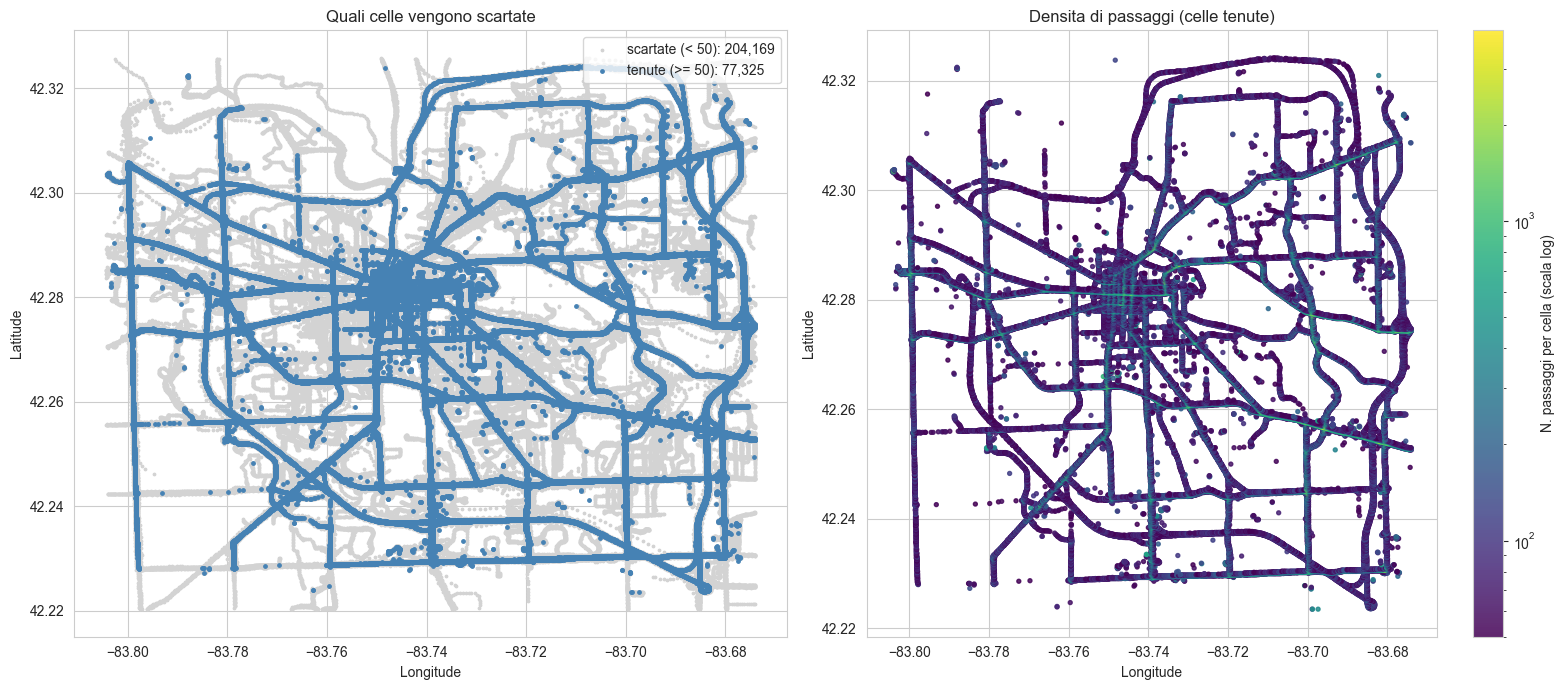

In [4]:
from matplotlib.colors import LogNorm

MIN_PASSAGES = 50
mask_keep = agg['n_passages'] >= MIN_PASSAGES
print(f"Celle: {len(agg):,} totali -> {mask_keep.sum():,} tenute, "
      f"{(~mask_keep).sum():,} scartate (< {MIN_PASSAGES} passaggi)")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# SINISTRA: QUALI celle si scartano (grigio) vs si tengono (blu) — rende visibile lo scarto
ax = axes[0]
ax.scatter(agg.loc[~mask_keep, 'lon_bin'], agg.loc[~mask_keep, 'lat_bin'],
           s=3, c='lightgray', label=f'scartate (< {MIN_PASSAGES}): {(~mask_keep).sum():,}')
ax.scatter(agg.loc[mask_keep, 'lon_bin'], agg.loc[mask_keep, 'lat_bin'],
           s=6, c='steelblue', label=f'tenute (>= {MIN_PASSAGES}): {mask_keep.sum():,}')
ax.set_title('Quali celle vengono scartate')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(loc='upper right')

# DESTRA: densita di passaggi sulle tenute, scala LOG
# (con scala lineare gli outlier a ~4000 schiacciano tutto il resto sul fondo -> "sembra vuoto")
ax = axes[1]
kept = agg[mask_keep]
sc = ax.scatter(kept['lon_bin'], kept['lat_bin'], c=kept['n_passages'],
                cmap='viridis', s=8, alpha=0.85,
                norm=LogNorm(vmin=MIN_PASSAGES, vmax=kept['n_passages'].max()))
plt.colorbar(sc, ax=ax, label='N. passaggi per cella (scala log)')
ax.set_title('Densita di passaggi (celle tenute)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

# Applica il filtro DOPO aver disegnato (cosi il pannello sinistro puo mostrare anche le scartate)
agg = agg[mask_keep].reset_index(drop=True)

## 3. Selezione delle feature per il clustering

Feature scelte: **cinematica + geometria** del tratto — velocità (media/std), accelerazione
(media/std/abs), frazione di sosta (`stop_fraction`) e pendenza (`slope_mean`).

**Escludiamo i segnali-motore** `maf_mean`, `rpm_mean`, `load_mean`: (a) sono **ridondanti** tra loro
(RPM/Load correlano col MAF 0,75 e 0,52) e **sovrappesano** la dimensione "sforzo motore"; (b)
codificano il **consumo**, quindi renderebbero il cluster *leaky* e non riutilizzabile in un modello
di consumo. È lo **stesso criterio della Parte B** (stili di guida), che usa solo cinematica → un
"tipo di strada" è definito da *come ci si muove e dalla geometria*, non da quanto consuma il motore
(che è una conseguenza). I segnali-motore restano comunque calcolati in `agg` e si possono mostrare
*a posteriori* per interpretare i cluster.

Escludiamo anche `n_passages` (meta-dato), `elevation` (quota **assoluta** → identificherebbe il
*luogo*, non il *tipo*) e le coordinate (stesso motivo: non vogliamo "vicinato A vs B").

In [5]:
FEATURES_CLUSTER = [
    'speed_mean', 'speed_std',
    'accel_mean', 'accel_std', 'accel_abs_mean',
    'slope_mean', 'stop_fraction'
]
# Esclusi di proposito maf_mean/rpm_mean/load_mean (segnali-motore): ridondanti + rendono il
# cluster leaky rispetto al consumo. Solo cinematica + geometria (coerente con la Parte B).

X = agg[FEATURES_CLUSTER].copy()
X = X.dropna()  # alcune celle potrebbero avere std NaN con un solo passaggio
agg_clean = agg.loc[X.index].reset_index(drop=True)
X = X.reset_index(drop=True)
print(f"Celle finali per clustering: {len(X):,}")
print(f"Feature: {len(FEATURES_CLUSTER)}")

X.describe()

Celle finali per clustering: 77,325
Feature: 7


,speed_mean,speed_std,accel_mean,accel_std,accel_abs_mean,slope_mean,stop_fraction
count,77325.000000,77325.000000,77325.000000,77325.000000,77325.000000,77325.000000,77325.000000
mean,46.282219,14.307227,-0.146671,3.614341,1.773129,0.000124,0.077770
std,23.008968,7.086949,0.903107,0.937117,0.670067,0.018218,0.159084
min,0.000000,0.000000,-5.249651,0.000000,0.000000,-0.082192,0.000000
25%,29.344944,8.913104,-0.632350,2.974992,1.295158,-0.006121,0.000000
50%,46.254467,13.176139,-0.132034,3.613687,1.688191,0.000000,0.000000
75%,58.077103,18.334269,0.346891,4.244734,2.176733,0.006000,0.084112
max,121.697365,57.487869,4.166846,7.239012,5.437530,0.081307,1.000000


## 4. Standardizzazione — perché è obbligatoria

Guarda le scale delle feature:
- `speed_mean`: 0–120 km/h
- `speed_std`: 0–55
- `accel_std`: 0–7
- `stop_fraction`: 0–1
- `slope_mean`: -0.08 a 0.08

Senza standardizzazione, K-Means calcolerebbe la distanza euclidea **dominata da `speed_mean`** (range
di gran lunga più ampio), mentre `slope_mean` e `stop_fraction` sarebbero trascurate. Lo StandardScaler
riporta tutte le feature a media 0 e std 1, così pesano allo stesso modo.

In [6]:
# Esempio: cluster fatti SENZA standardizzazione (didattico)
demo_km = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE).fit(X)
print("Senza scaling, importanza relativa delle feature nella distanza euclidea:")
var_contrib = X.var() / X.var().sum()
print((var_contrib * 100).round(2).sort_values(ascending=False))
print("\n→ Le feature con range grande dominano TUTTO il clustering. Inaccettabile.\n")

# Ora con scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES_CLUSTER)
print("Dopo standardizzazione:")
print(X_scaled_df.describe().loc[['mean', 'std']].round(3))

Senza scaling, importanza relativa delle feature nella distanza euclidea:
speed_mean        90.99
speed_std          8.63
accel_std          0.15
accel_mean         0.14
accel_abs_mean     0.08
slope_mean         0.00
stop_fraction      0.00
dtype: float64

→ Le feature con range grande dominano TUTTO il clustering. Inaccettabile.

Dopo standardizzazione:
      speed_mean  speed_std  accel_mean  accel_std  accel_abs_mean  \
mean         0.0        0.0        -0.0       -0.0            -0.0   
std          1.0        1.0         1.0        1.0             1.0   

      slope_mean  stop_fraction  
mean         0.0            0.0  
std          1.0            1.0  


## 5. Scelta di K — Elbow Method + Silhouette

Proviamo K da 2 a 10. Per ogni K calcoliamo:
- **inerzia** (WCSS): somma dei quadrati delle distanze dai centroidi. Decresce sempre con K, ma il punto in cui rallenta è il "gomito".
- **silhouette score**: misura quanto i cluster sono ben separati. Va da -1 a 1, più alto è meglio.

  k=2: inertia=423786, silhouette=0.227
  k=3: inertia=353914, silhouette=0.250
  k=4: inertia=312365, silhouette=0.254
  k=5: inertia=271749, silhouette=0.246
  k=6: inertia=246614, silhouette=0.257
  k=7: inertia=223410, silhouette=0.245
  k=8: inertia=206727, silhouette=0.219
  k=9: inertia=192350, silhouette=0.226
  k=10: inertia=183357, silhouette=0.210


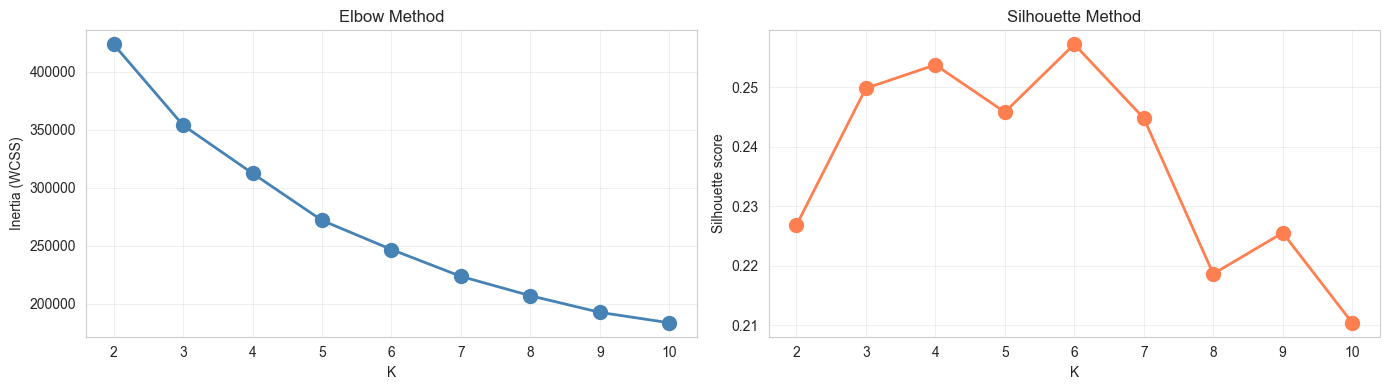

In [7]:
K_VALUES = list(range(2, 11))
inertias = []
silhouettes = []

# Silhouette è costosa: usiamo un sample per K alti
if len(X_scaled) > 10000:
    sil_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), size=10000, replace=False)
else:
    sil_idx = np.arange(len(X_scaled))

for k in K_VALUES:
    km = KMeans(n_clusters=k, n_init=20, init='k-means++', random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled[sil_idx], labels[sil_idx])
    silhouettes.append(sil)
    print(f"  k={k}: inertia={km.inertia_:.0f}, silhouette={sil:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(K_VALUES, inertias, 'o-', color='steelblue', lw=2, markersize=10)
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_VALUES, silhouettes, 'o-', color='coral', lw=2, markersize=10)
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette Method')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.1 Scelta finale di K

Combinando elbow (dove la pendenza dell'inerzia cambia bruscamente) e silhouette (massimo locale), tipicamente troveremo un buon valore tra **4 e 6**. Scegli il K che vedi essere il gomito; modifica `K_FINAL` se diverso.

In [35]:
# Default: prendiamo il K con miglior silhouette tra i "ragionevoli" (≥3, ≤7)
K_FINAL = K_VALUES[np.argmax([s if 3 <= k <= 7 else -1 for k, s in zip(K_VALUES, silhouettes)])]
print(f"K scelto: {K_FINAL}")
print("Puoi modificare K_FINAL manualmente se preferisci un altro valore basandoti sul gomito.")
K_FINAL=4

K scelto: 6
Puoi modificare K_FINAL manualmente se preferisci un altro valore basandoti sul gomito.


## 6. K-Means finale

Eseguiamo il K-Means con K scelto, `n_init=50` per ridurre il rischio di minimo locale, e K-Means++ come strategia di inizializzazione (sceglie centroidi iniziali distanti tra loro).

In [36]:
kmeans = KMeans(n_clusters=K_FINAL, n_init=50, init='k-means++', random_state=RANDOM_STATE)
labels = kmeans.fit_predict(X_scaled)
agg_clean['cluster'] = labels

print("Distribuzione dei cluster:")
print(agg_clean['cluster'].value_counts().sort_index())

Distribuzione dei cluster:
cluster
0    31792
1     7951
2     5738
3    31844
Name: count, dtype: int64


## 7. Caratterizzazione e naming dei cluster

**Questa è la sezione più importante del progetto.** Cluster senza interpretazione sono inutili. Per
ogni cluster guardiamo le feature medie e gli diamo un nome interpretativo.

> **Feature di clustering vs colonna descrittiva.** Le colonne in `FEATURES_CLUSTER` (cinematica +
> geometria) sono quelle che *formano* i cluster. Aggiungiamo `maf_mean_descr` (consumo medio) come
> colonna **puramente descrittiva**: **non** entra nel K-Means, serve solo a *interpretare* i cluster
> a posteriori. Se i tratti — separati solo su *come ci si muove* — risultano diversi anche nel
> **consumo**, è un **risultato**, non una conseguenza obbligata (è il motivo per cui il MAF non è
> tra le feature di clustering).

In [37]:
# Profilo dei cluster: medie delle FEATURE DI CLUSTERING (cinematica + geometria)
cluster_profile = agg_clean.groupby('cluster')[FEATURES_CLUSTER + ['n_passages']].mean().round(2)
cluster_profile['count'] = agg_clean['cluster'].value_counts().sort_index()

# --- Colonna DESCRITTIVA (NON usata per clusterizzare) ---
# Consumo medio per tipologia di tratto. I cluster sono formati SOLO su cinematica+geometria:
# se risultano separati anche nel consumo e' un RISULTATO a posteriori, non una tautologia.
cluster_profile['maf_mean_descr'] = agg_clean.groupby('cluster')['maf_mean'].mean().round(2)

cluster_profile

,speed_mean,speed_std,accel_mean,accel_std,accel_abs_mean,slope_mean,stop_fraction,n_passages,count,maf_mean_descr
cluster,,,,,,,,,,
0,33.740002,15.530000,-0.30,4.46,2.38,0.0,0.08,242.33,31792,9.45
1,79.250000,27.139999,0.00,3.07,1.38,-0.0,0.03,122.76,7951,16.74
2,11.110000,13.280000,-0.08,2.95,1.14,-0.0,0.53,275.58,5738,6.31
3,56.910000,10.070000,-0.04,3.03,1.38,0.0,0.00,151.89,31844,10.23


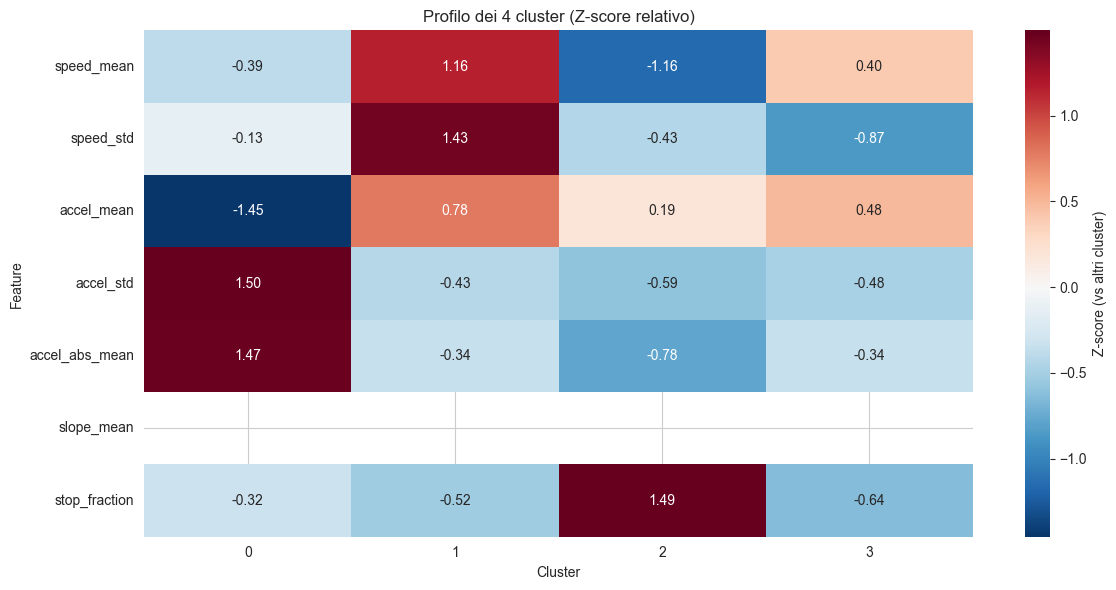

In [38]:
# Heatmap dei profili cluster (normalizzati su tutti i cluster per leggibilità)
profile_norm = (cluster_profile[FEATURES_CLUSTER] - cluster_profile[FEATURES_CLUSTER].mean()) / cluster_profile[FEATURES_CLUSTER].std()

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(profile_norm.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Z-score (vs altri cluster)'}, ax=ax)
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')
ax.set_title(f'Profilo dei {K_FINAL} cluster (Z-score relativo)')
plt.tight_layout()
plt.show()

### 7.1 Naming dei cluster

**ATTENZIONE: i cluster K-Means non hanno un ordinamento fisso** — a ogni riesecuzione gli stessi
pattern possono avere ID diversi. Per questo li nominiamo **in base ai valori del profilo**, non al
numero: così il nome resta corretto anche se gli ID si rimescolano.

**Logica di naming** (cella sotto), in ordine di priorità:
- `stop_fraction > 0,50` → **Incrocio/semaforo** (quasi sempre fermo)
- `stop_fraction > 0,18` → **Urbano stop-and-go** (molte soste, ma in movimento)
- `speed_mean ≥ 75` → **Autostrada/scorrimento veloce**
- `speed_mean ≥ 50` → **Scorrevole/arteria fluida** (veloce ma regolare)
- velocità moderata + poche soste → distinta per **segno dell'accelerazione media**:
  - `accel_mean > 0` → **Ripartenze/accelerazione**
  - `accel_mean < 0` → **Avvicinamento a incroci/decelerazione**

Le soglie sono cutoff **interpretabili** (regolabili). Verifica sempre col profilo/heatmap qui sopra.

In [39]:
# Naming dei cluster basato sui VALORI del profilo (robusto al rinumeramento del K-Means).
# Logica: frazione di sosta -> livello di velocita' -> segno dell'accelerazione media.
def name_cluster(row):
    sp, stop, am = row['speed_mean'], row['stop_fraction'], row['accel_mean']
    if stop > 0.50:                       # fermo per la maggior parte del tempo
        return 'Incrocio/semaforo (quasi fermo)'
    if stop > 0.18:                       # molte soste, ma in movimento
        return 'Urbano stop-and-go'
    if sp >= 75:                          # alta velocita', quasi nessuna sosta
        return 'Autostrada/scorrimento veloce'
    if sp >= 50:                          # velocita' sostenuta e regolare
        return 'Scorrevole/arteria fluida'
    # velocita' moderata + poche soste: distinguo per il segno dell'accelerazione media
    if am > 0.4:
        return 'Ripartenze/tratto in accelerazione'
    if am < -0.4:
        return 'Avvicinamento a incroci/decelerazione'
    return 'Cittadino misto'

cluster_profile['cluster_name'] = cluster_profile.apply(name_cluster, axis=1)
cluster_names = cluster_profile['cluster_name'].to_dict()

print("Naming (assegnato dai valori del profilo):")
for k, v in cluster_names.items():
    print(f"  Cluster {k}: {v:42s} "
          f"[speed={cluster_profile.loc[k, 'speed_mean']:.0f}, "
          f"stop={cluster_profile.loc[k, 'stop_fraction']:.2f}, "
          f"accel_mean={cluster_profile.loc[k, 'accel_mean']:+.2f}]")

# Mappa l'etichetta nei dati
agg_clean['cluster_name'] = agg_clean['cluster'].map(cluster_names)

Naming (assegnato dai valori del profilo):
  Cluster 0: Cittadino misto                            [speed=34, stop=0.08, accel_mean=-0.30]
  Cluster 1: Autostrada/scorrimento veloce              [speed=79, stop=0.03, accel_mean=+0.00]
  Cluster 2: Incrocio/semaforo (quasi fermo)            [speed=11, stop=0.53, accel_mean=-0.08]
  Cluster 3: Scorrevole/arteria fluida                  [speed=57, stop=0.00, accel_mean=-0.04]


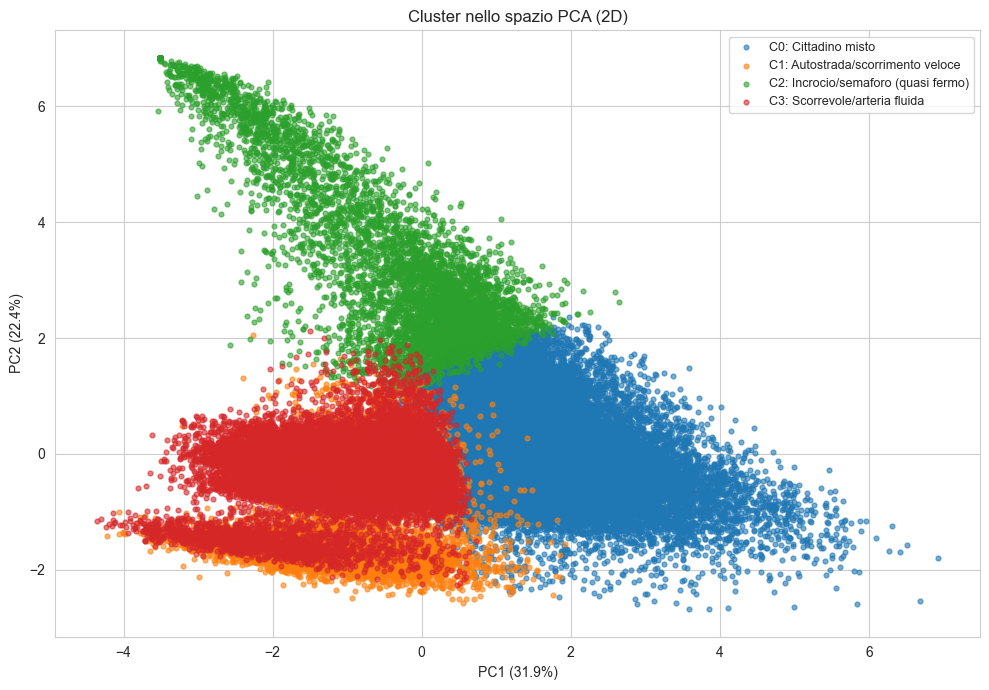

In [40]:
fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette('tab10', K_FINAL)
for c in sorted(agg_clean['cluster'].unique()):
    mask = agg_clean['cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=12, alpha=0.6, color=palette[c],
               label=f'C{c}: {cluster_names[c]}')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Cluster nello spazio PCA (2D)')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

## 9. Visualizzazione geografica — la mappa di Ann Arbor

**Questa è la sezione "deliverable visivo"** del progetto. Coloriamo la mappa di Ann Arbor con i cluster, ottenendo una vera classificazione geografica dei tipi di tratto stradale.

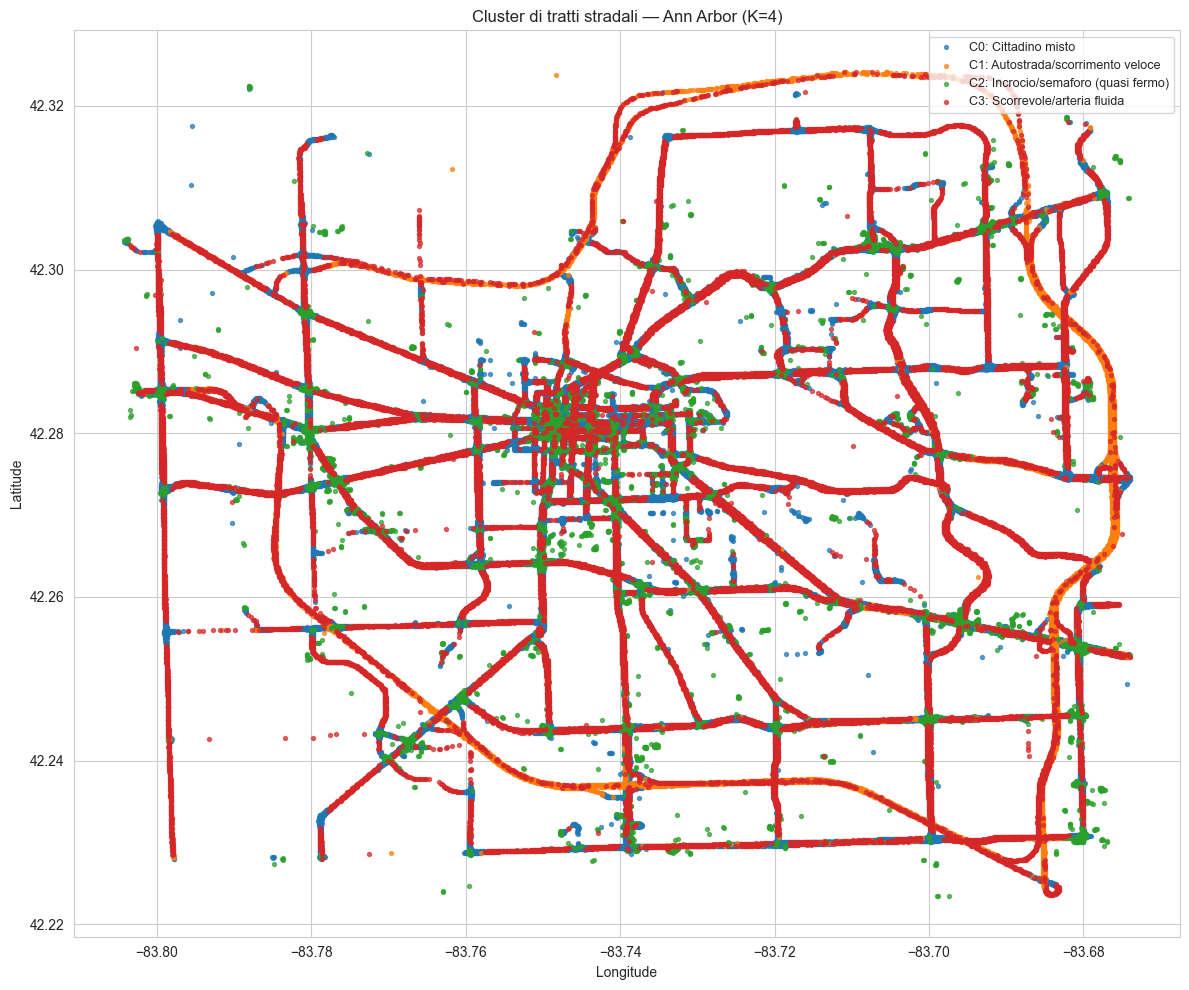

In [41]:
# Plot statico (matplotlib) — sempre disponibile
fig, ax = plt.subplots(figsize=(12, 10))
for c in sorted(agg_clean['cluster'].unique()):
    mask = agg_clean['cluster'] == c
    ax.scatter(agg_clean.loc[mask, 'lon_bin'], agg_clean.loc[mask, 'lat_bin'],
               s=8, alpha=0.7, color=palette[c],
               label=f'C{c}: {cluster_names[c]}')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Cluster di tratti stradali — Ann Arbor (K={K_FINAL})')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('./outputs/cluster_map_static.png', dpi=120, bbox_inches='tight')
plt.show()

In [42]:
try:
    import folium
    center = [agg_clean['lat_bin'].mean(), agg_clean['lon_bin'].mean()]
    m = folium.Map(location=center, zoom_start=13, tiles='cartodbpositron')

    # Palette hex per folium
    palette_hex = [f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}'
                   for r, g, b in palette]

    # Subsample per non appesantire la mappa (~10k punti totali)
    plot_df = agg_clean.sample(n=min(10000, len(agg_clean)), random_state=RANDOM_STATE)

    # Un FeatureGroup per ogni cluster -> diventa una voce SPUNTABILE nel controllo dei layer.
    # show=True: parte visibile; togli la spunta per nascondere quel cluster.
    for c in sorted(agg_clean['cluster'].unique()):
        fg = folium.FeatureGroup(name=f'C{c}: {cluster_names[c]}', show=True)
        sub = plot_df[plot_df['cluster'] == c]
        for _, row in sub.iterrows():
            folium.CircleMarker(
                location=[row['lat_bin'], row['lon_bin']],
                radius=3,
                color=palette_hex[c],
                fill=True,
                fill_opacity=0.7,
                popup=f"Cluster {c}: {cluster_names[c]}<br>"
                      f"Speed={row['speed_mean']:.1f} km/h<br>"
                      f"MAF={row['maf_mean']:.1f} g/s<br>"
                      f"Stop frac={row['stop_fraction']:.2f}"
            ).add_to(fg)
        fg.add_to(m)

    # Pannello di controllo: spunta/togli ogni cluster (overlay -> caselle multiple, non radio).
    # collapsed=False lo lascia aperto cosi si vede subito.
    folium.LayerControl(collapsed=False).add_to(m)

    # Legenda colori (il pannello dei layer mostra i nomi, questa mostra i colori)
    legend_html = ('<div style="position: fixed; bottom: 30px; left: 30px; width: 250px; '
                   'background: white; border:2px solid grey; padding: 10px; z-index: 1000;">'
                   '<b>Colori cluster</b><br>')
    for c, name in cluster_names.items():
        legend_html += (f'<i style="background:{palette_hex[c]}; width:12px; height:12px; '
                        f'display:inline-block;"></i> C{c}: {name}<br>')
    legend_html += '</div>'
    m.get_root().html.add_child(folium.Element(legend_html))

    OUT_MAP = Path('./outputs/cluster_map.html')
    m.save(str(OUT_MAP))
    print(f"✓ Mappa interattiva salvata: {OUT_MAP}")
    print("  Apri il file HTML: usa il pannello in alto a destra per mostrare/nascondere i cluster.")
except ImportError:
    print("folium non installato. Installa con: pip install folium")
    print("Per ora va bene la mappa statica salvata sopra.")

✓ Mappa interattiva salvata: outputs\cluster_map.html
  Apri il file HTML: usa il pannello in alto a destra per mostrare/nascondere i cluster.


## 11. Confronto cluster ↔ EngineType (sanity check)

Per ogni cluster di tratto stradale, qual è la composizione di EngineType dei veicoli che lo percorrono? In teoria dovrebbe essere abbastanza uniforme (i veicoli HEV percorrono le stesse strade degli ICE), ma se c'è una differenza è interessante.

Composizione EngineType per cluster (%):
EngineType                                HEV   ICE  PHEV
cluster cluster_name                                     
0       Cittadino misto                  29.4  58.0  12.5
1       Autostrada/scorrimento veloce    29.0  60.8  10.2
2       Incrocio/semaforo (quasi fermo)  17.8  76.1   6.1
3       Scorrevole/arteria fluida        32.7  51.6  15.7


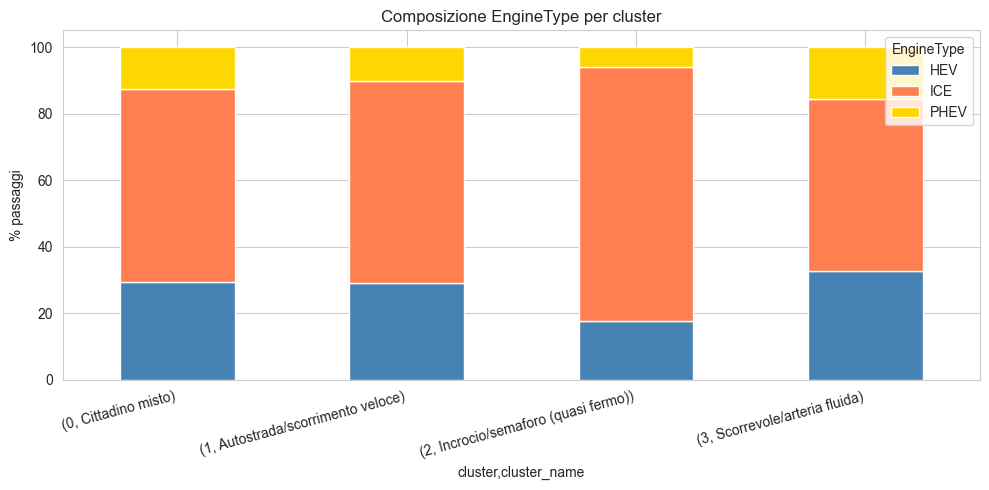

In [43]:
# Per ogni cella prendiamo la proporzione di passaggi per EngineType
engine_breakdown = df.merge(
    agg_clean[['lat_bin', 'lon_bin', 'cluster', 'cluster_name']],
    on=['lat_bin', 'lon_bin'], how='inner'
).groupby(['cluster', 'cluster_name', 'EngineType']).size().unstack(fill_value=0)
engine_breakdown_pct = engine_breakdown.div(engine_breakdown.sum(axis=1), axis=0) * 100

print("Composizione EngineType per cluster (%):")
print(engine_breakdown_pct.round(1))

engine_breakdown_pct.plot(kind='bar', stacked=True, figsize=(10, 5),
                          color=['steelblue', 'coral', 'gold'])
plt.ylabel('% passaggi')
plt.title('Composizione EngineType per cluster')
plt.xticks(rotation=15, ha='right')
plt.legend(title='EngineType', loc='upper right')
plt.tight_layout()
plt.show()

## 12. Salvataggio dei risultati

In [44]:
agg_clean.to_parquet('./outputs/road_segment_clusters.parquet', index=False)
cluster_profile.to_csv('./outputs/cluster_profile.csv')
print("✓ Salvati:")
print("  outputs/road_segment_clusters.parquet (segmenti con etichetta cluster)")
print("  outputs/cluster_profile.csv (profilo numerico dei cluster)")
print("  outputs/cluster_map_static.png (mappa)")
print("  outputs/cluster_map.html (mappa interattiva se folium installato)")

✓ Salvati:
  outputs/road_segment_clusters.parquet (segmenti con etichetta cluster)
  outputs/cluster_profile.csv (profilo numerico dei cluster)
  outputs/cluster_map_static.png (mappa)
  outputs/cluster_map.html (mappa interattiva se folium installato)


---
# Parte B — Stili di guida e confronto tra powertrain

Finora (Parte A) abbiamo clusterizzato i **tratti di strada**. Ora cambiamo unita': il **guidatore**
(`VehId`). Caratterizziamo lo **stile di guida** dalla sola **cinematica** (velocita', accelerazioni,
soste) — niente MAF/RPM. Questo e' fondamentale: la cinematica e' **valida e confrontabile per tutti
e tre i powertrain** (ICE/HEV/PHEV), mentre il consumo (MAF) no (per gli ibridi il motore si spegne).

Cosi' possiamo finalmente **confrontare i tre tipi di motore** in modo onesto: *i powertrain vengono
guidati in modo diverso?* E (solo per gli ICE, dove il MAF e' valido) *lo stile incide sul consumo?*

## B.1 Profilo cinematico per guidatore

Aggreghiamo la telemetria per `VehId`: velocita' media/variabilita'/crociera (p85), accelerazione
media e brusca, frenate brusche, frazione di sosta. Niente MAF/RPM -> feature powertrain-agnostiche.

In [45]:
g = df.groupby('VehId')
driver = g.agg(
    EngineType=('EngineType', 'first'),
    n=('VehId', 'size'),
    speed_mean=('Vehicle_Speed_km_per_h', 'mean'),
    speed_std=('Vehicle_Speed_km_per_h', 'std'),
    speed_p85=('Vehicle_Speed_km_per_h', lambda s: s.quantile(0.85)),
    accel_abs_mean=('accel_kmh_s', lambda s: s.abs().mean()),
    accel_std=('accel_kmh_s', 'std'),
    frac_hard_accel=('accel_kmh_s', lambda s: (s > 6).mean()),
    frac_hard_decel=('accel_kmh_s', lambda s: (s < -6).mean()),
    stop_fraction=('Vehicle_Speed_km_per_h', lambda s: (s < 2).mean()),
).reset_index()

driver = driver[driver['n'] >= 2000].reset_index(drop=True)   # guidatori con dati sufficienti
STYLE_FEATURES = ['speed_mean','speed_std','speed_p85','accel_abs_mean','accel_std',
                  'frac_hard_accel','frac_hard_decel','stop_fraction']
print(f"Guidatori: {len(driver)} | per EngineType:")
print(driver['EngineType'].value_counts().to_string())
driver[STYLE_FEATURES].describe().round(3)

Guidatori: 278 | per EngineType:
EngineType
ICE     177
HEV      89
PHEV     12


,speed_mean,speed_std,speed_p85,accel_abs_mean,accel_std,frac_hard_accel,frac_hard_decel,stop_fraction
count,278.000,278.000,278.000,278.000,278.000,278.000,278.000,278.000
mean,41.036,25.798,66.956,1.828,3.918,0.057,0.056,0.114
std,7.869,4.614,11.911,0.243,0.286,0.009,0.008,0.082
min,8.020,14.447,23.000,0.817,2.737,0.026,0.026,0.000
25%,35.747,22.415,60.250,1.698,3.762,0.052,0.051,0.037
50%,40.423,25.262,64.000,1.841,3.950,0.058,0.055,0.124
75%,45.642,28.474,69.060,2.006,4.118,0.063,0.061,0.160
max,69.748,42.003,118.000,2.403,4.663,0.081,0.084,0.667


## B.2 Standardizzazione e scelta di K (elbow + silhouette)

  k=2: inertia=1552, silhouette=0.287
  k=3: inertia=1218, silhouette=0.290
  k=4: inertia=1050, silhouette=0.228
  k=5: inertia=912, silhouette=0.246
  k=6: inertia=807, silhouette=0.250
  k=7: inertia=714, silhouette=0.256
  k=8: inertia=646, silhouette=0.262


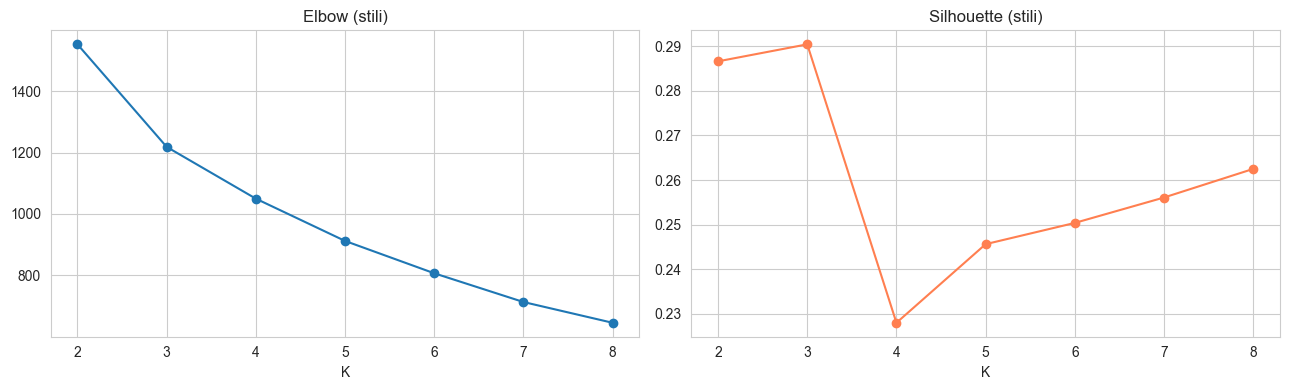

K scelto (stili): 3 (modifica a mano se preferisci il gomito)


In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Xs = StandardScaler().fit_transform(driver[STYLE_FEATURES])
Ks = list(range(2, 9)); inertias=[]; sils=[]
for k in Ks:
    km = KMeans(n_clusters=k, n_init=20, init='k-means++', random_state=RANDOM_STATE).fit(Xs)
    inertias.append(km.inertia_); sils.append(silhouette_score(Xs, km.labels_))
    print(f"  k={k}: inertia={km.inertia_:.0f}, silhouette={sils[-1]:.3f}")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(Ks, inertias, 'o-'); axes[0].set_title('Elbow (stili)'); axes[0].set_xlabel('K')
axes[1].plot(Ks, sils, 'o-', color='coral'); axes[1].set_title('Silhouette (stili)'); axes[1].set_xlabel('K')
plt.tight_layout(); plt.show()
K_STYLE = Ks[int(np.argmax([s if 3 <= k <= 6 else -1 for k, s in zip(Ks, sils)]))]
print("K scelto (stili):", K_STYLE, "(modifica a mano se preferisci il gomito)")

## B.3 K-Means, profilo e naming degli stili

Naming euristico da rivedere guardando la heatmap (come per i cluster stradali).

       speed_mean  speed_std  speed_p85  accel_abs_mean  accel_std  frac_hard_accel  frac_hard_decel  stop_fraction    n
style                                                                                                                   
0       36.113998  24.745001  60.835999           1.591      3.658            0.049            0.049          0.159   91
1       40.201000  24.080999  63.639000           1.996      4.121            0.063            0.061          0.095  131
2       50.990002  31.524000  84.662003           1.820      3.865            0.056            0.054          0.085   56


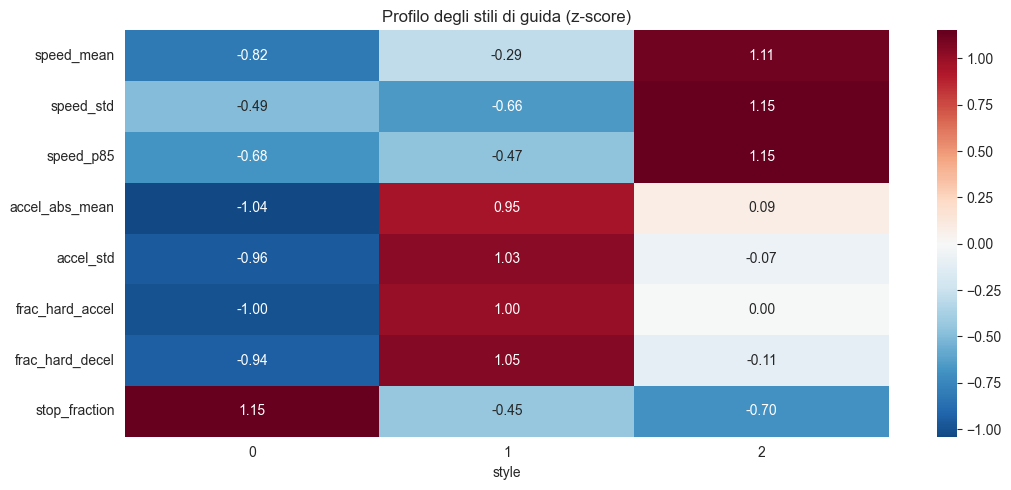


Naming proposto: {0: 'Urbano stop-and-go', 1: 'Aggressivo', 2: 'Crociera/extraurbano'}


In [47]:
km = KMeans(n_clusters=K_STYLE, n_init=50, init='k-means++', random_state=RANDOM_STATE)
driver['style'] = km.fit_predict(Xs)
prof = driver.groupby('style')[STYLE_FEATURES].mean().round(3)
prof['n'] = driver['style'].value_counts().sort_index()
print(prof.to_string())

prof_z = (prof[STYLE_FEATURES] - prof[STYLE_FEATURES].mean()) / prof[STYLE_FEATURES].std()
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(prof_z.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Profilo degli stili di guida (z-score)'); plt.tight_layout(); plt.show()

def name_style(r):
    if r['stop_fraction'] > prof['stop_fraction'].quantile(0.66): return 'Urbano stop-and-go'
    if r['frac_hard_accel'] + r['frac_hard_decel'] > (prof['frac_hard_accel']+prof['frac_hard_decel']).quantile(0.66): return 'Aggressivo'
    if r['speed_p85'] > prof['speed_p85'].quantile(0.66): return 'Crociera/extraurbano'
    return 'Moderato'
style_names = {i: name_style(prof.loc[i]) for i in prof.index}
driver['style_name'] = driver['style'].map(style_names)
print("\nNaming proposto:", style_names)

## B.4 PCA degli stili

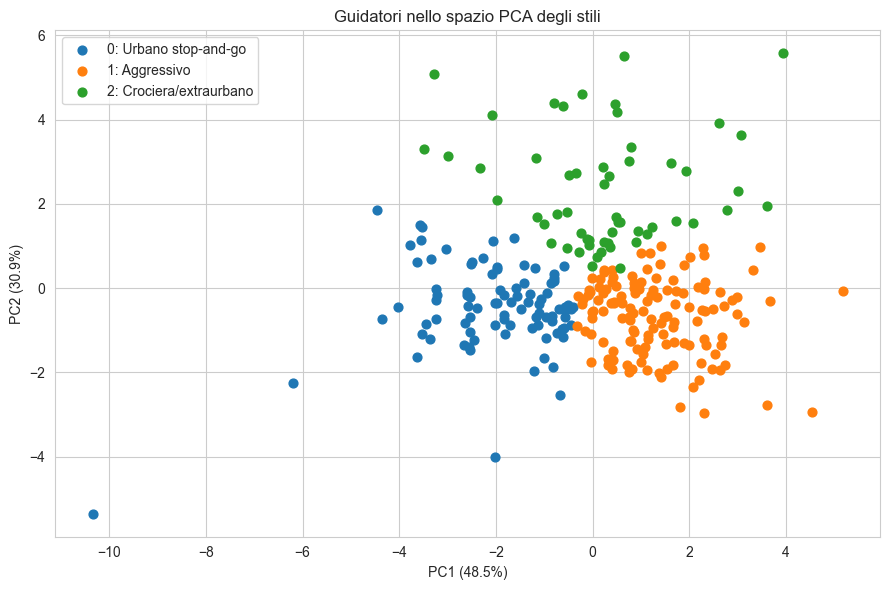

In [48]:
from sklearn.decomposition import PCA
pca_s = PCA(n_components=2, random_state=RANDOM_STATE)
Zs = pca_s.fit_transform(Xs)
fig, ax = plt.subplots(figsize=(9, 6))
pal = sns.color_palette('tab10', K_STYLE)
for c in sorted(driver['style'].unique()):
    m = driver['style'] == c
    ax.scatter(Zs[m, 0], Zs[m, 1], s=40, color=pal[c], label=f"{c}: {style_names[c]}")
ax.set_xlabel(f'PC1 ({pca_s.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_s.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Guidatori nello spazio PCA degli stili'); ax.legend(); plt.tight_layout(); plt.show()

## B.5 Stile di guida x tipo di motore (la domanda chiave)

I tre powertrain vengono guidati diversamente? Tabella di contingenza stile x EngineType + test
chi-quadro (le distribuzioni differiscono in modo statisticamente significativo?).

Conteggi (stile x EngineType):
EngineType            HEV  ICE  PHEV
style_name                          
Aggressivo             61   67     3
Crociera/extraurbano   19   34     3
Urbano stop-and-go      9   76     6

% per colonna (composizione di stile DENTRO ogni powertrain):
EngineType             HEV   ICE  PHEV
style_name                            
Aggressivo            68.5  37.9  25.0
Crociera/extraurbano  21.3  19.2  25.0
Urbano stop-and-go    10.1  42.9  50.0

Chi-quadro: chi2=34.05, dof=4, p=0.0000  -> differenze significative


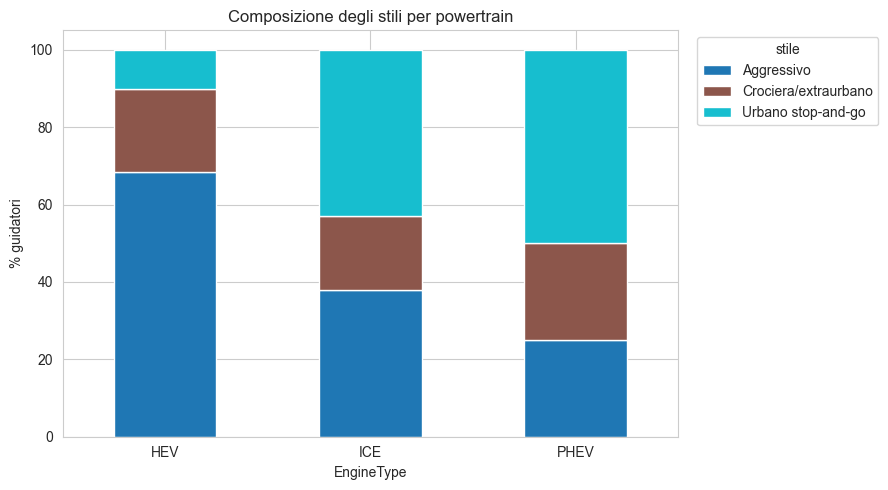

In [49]:
from scipy.stats import chi2_contingency
ct = pd.crosstab(driver['style_name'], driver['EngineType'])
ct_pct = pd.crosstab(driver['style_name'], driver['EngineType'], normalize='columns') * 100
print("Conteggi (stile x EngineType):"); print(ct.to_string())
print("\n% per colonna (composizione di stile DENTRO ogni powertrain):"); print(ct_pct.round(1).to_string())
chi2, p, dof, _ = chi2_contingency(ct)
print(f"\nChi-quadro: chi2={chi2:.2f}, dof={dof}, p={p:.4f}  -> {'differenze significative' if p<0.05 else 'nessuna differenza significativa'}")
ct_pct.T.plot(kind='bar', stacked=True, figsize=(9,5), colormap='tab10')
plt.ylabel('% guidatori'); plt.title('Composizione degli stili per powertrain'); plt.xticks(rotation=0)
plt.legend(title='stile', bbox_to_anchor=(1.02,1)); plt.tight_layout(); plt.show()

## B.6 (Solo ICE) lo stile incide sul consumo?

Dove il MAF e' valido (ICE), calcoliamo il consumo per km di ogni guidatore e lo confrontiamo tra
gli stili. E' il payoff eco-driving: lo stile aggressivo/stop-and-go costa di piu'?

Consumo medio (g/km) per stile (solo ICE):
                        mean  median  count
style_name                                 
Aggressivo            1108.7  1074.2     67
Crociera/extraurbano  1044.9   993.3     34
Urbano stop-and-go    1193.0  1047.7     76


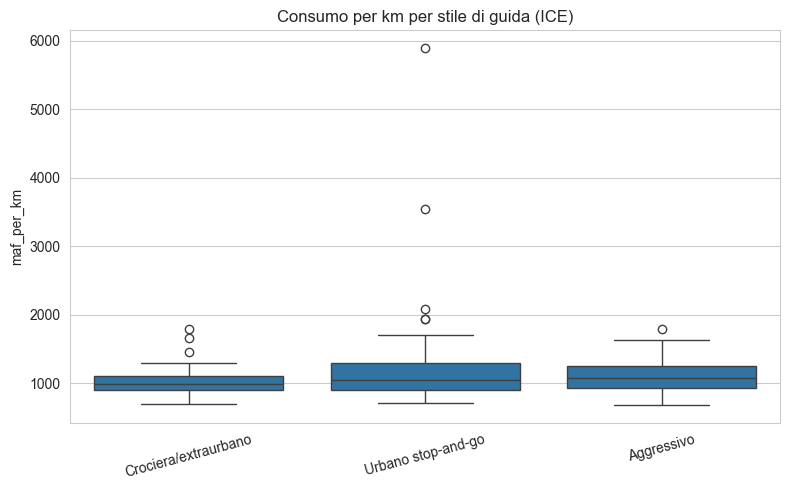

In [50]:
ice = df[df['EngineType'] == 'ICE'].copy()
ice['dt_s'] = (ice['dt_ms'].fillna(0)/1000).clip(0, 2)
cons = ice.groupby('VehId').apply(
    lambda d: (d['MAF_g_per_sec']*d['dt_s']).sum() / max(d['dist_m'].fillna(0).sum()/1000, 1e-6)
).rename('maf_per_km')
dcons = driver[driver['EngineType']=='ICE'].merge(cons, on='VehId', how='inner')
print("Consumo medio (g/km) per stile (solo ICE):")
print(dcons.groupby('style_name')['maf_per_km'].agg(['mean','median','count']).round(1).to_string())
fig, ax = plt.subplots(figsize=(8,5))
order = dcons.groupby('style_name')['maf_per_km'].median().sort_values().index
sns.boxplot(data=dcons, x='style_name', y='maf_per_km', order=order, ax=ax)
ax.set_title('Consumo per km per stile di guida (ICE)'); ax.set_xlabel(''); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

## B.7 Confronto energetico tra powertrain (descrittivo)

Perche' gli ibridi non possono entrare nel modello di consumo: caratterizziamoli. (1) frazione di
**motore spento in marcia** (trazione elettrica); (2) **MAF in decelerazione** = firma della frenata
rigenerativa (gli ibridi vanno a ~0, l'ICE no).

            motore_spento_in_marcia_%  MAF_medio_in_decel
EngineType                                               
ICE                               0.0                5.86
HEV                              21.0                2.42
PHEV                             24.4                1.46


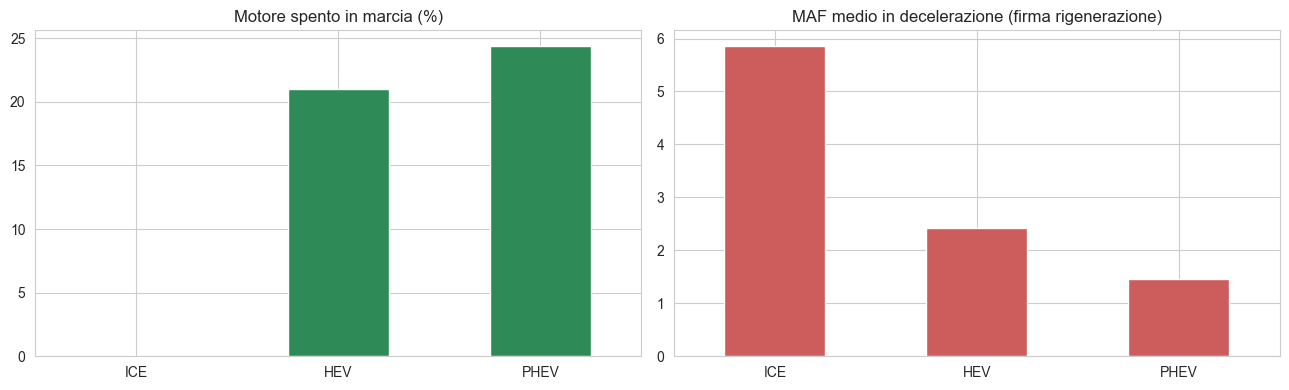


Lettura: ICE consuma aria anche in decel (motore sempre acceso); HEV/PHEV ~0 -> motore spento + frenata rigenerativa.


In [51]:
mov = df[df['Vehicle_Speed_km_per_h'] > 5]
eng_off = mov.assign(off=(mov['MAF_g_per_sec'] < 0.5)).groupby('EngineType')['off'].mean()*100
decel = df[(df['accel_kmh_s'] < -3) & (df['Vehicle_Speed_km_per_h'] > 5)]
maf_decel = decel.groupby('EngineType')['MAF_g_per_sec'].mean()
comp = pd.DataFrame({'motore_spento_in_marcia_%': eng_off.round(1), 'MAF_medio_in_decel': maf_decel.round(2)})
comp = comp.reindex(['ICE','HEV','PHEV'])
print(comp.to_string())
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
comp['motore_spento_in_marcia_%'].plot(kind='bar', ax=axes[0], color='seagreen')
axes[0].set_title('Motore spento in marcia (%)'); axes[0].set_xlabel(''); axes[0].tick_params(axis='x', rotation=0)
comp['MAF_medio_in_decel'].plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('MAF medio in decelerazione (firma rigenerazione)'); axes[1].set_xlabel(''); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()
print("\nLettura: ICE consuma aria anche in decel (motore sempre acceso); HEV/PHEV ~0 -> motore spento + frenata rigenerativa.")

---

## Riepilogo finale

**Cosa abbiamo costruito:**
- Aggregazione spaziale dei 17M punti in ~migliaia di celle (~50×50 m)
- Filtro qualità (≥ 50 passaggi per cella)
- Standardizzazione con motivazione esplicita (dimostrazione del fallimento senza scaling)
- Elbow + Silhouette per scelta di K
- K-Means con K-Means++ e n_init=50
- Caratterizzazione e naming dei cluster con heatmap z-score
- PCA con interpretazione dei loadings
- t-SNE come visualizzazione alternativa
- Mappa geografica statica + interattiva di Ann Arbor con cluster
- Confronto cluster ↔ EngineType

**Collegamento con il Notebook 2:** l'etichetta `cluster_name` potrebbe essere usata come feature aggiuntiva nel modello supervised (concettualmente: "il modello sa che il prossimo tratto sarà di tipo X"). Questo chiude il cerchio della narrativa del cruise control adattivo predittivo.

**Limitazioni (da menzionare nella presentazione):**
- K-Means assume cluster sferici e di dimensione simile; alternative come DBSCAN o HDBSCAN potrebbero trovare cluster di forma diversa
- L'aggregazione spaziale a celle quadrate è approssimativa: una segmentazione vera su grafo stradale (OpenStreetMap) sarebbe più accurata
- I cluster sono dipendenti dall'area: applicare a un'altra città richiederebbe ri-training

---
## Riepilogo (NB3 — contesto stradale + stili di guida)

**Parte A — contesto stradale:** clustering dei tratti (celle spaziali) in tipologie di strada;
StandardScaler motivato, elbow+silhouette, K-Means++, heatmap, PCA, t-SNE, mappa Folium.

**Parte B — stili di guida x powertrain:** clustering dei **guidatori** sulla sola **cinematica**
(valida per tutti i powertrain), confronto **stile x EngineType** (chi-quadro), e — solo per gli ICE
(dove il MAF e' valido) — relazione **stile -> consumo**. Piu' il **confronto energetico** tra i tre
motori (motore spento in marcia, firma della rigenerazione), che spiega perche' gli ibridi non
entrano nel modello di consumo (NB2).

**Tecniche del corso:** StandardScaler, K-Means/K-Means++, elbow, silhouette, PCA + loadings, t-SNE.